# Handwritten Digit Recognition Using CNN

### Deep Learning Mini Project

This notebook uses the **MNIST handwritten digit dataset** to train a **Convolutional Neural Network (CNN)** that recognizes digits from **0 to 9**.

**Dataset:** 60,000 training images + 10,000 test images, each 28 × 28 grayscale.

## 1. Import Required Libraries

TensorFlow/Keras is used for the CNN, NumPy for numerical operations, Matplotlib for visualization, and scikit-learn for the confusion matrix.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Import the MNIST Dataset

Keras downloads the MNIST dataset automatically the first time this cell is executed. No manual collection of 70,000 images is required.

In [2]:
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", x_test.shape)
print("Testing labels :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


## 3. Explore the Dataset

Let's verify the number of images, image size, labels, and pixel range.

In [3]:
print("Number of training images:", len(x_train))
print("Number of testing images :", len(x_test))
print("Image dimensions        :", x_train.shape[1:])
print("Number of classes       :", len(np.unique(y_train)))
print("Classes                 :", np.unique(y_train))
print("Pixel range             :", x_train.min(), "to", x_train.max())

Number of training images: 60000
Number of testing images : 10000
Image dimensions        : (28, 28)
Number of classes       : 10
Classes                 : [0 1 2 3 4 5 6 7 8 9]
Pixel range             : 0 to 255


## 4. Display Sample Handwritten Digits

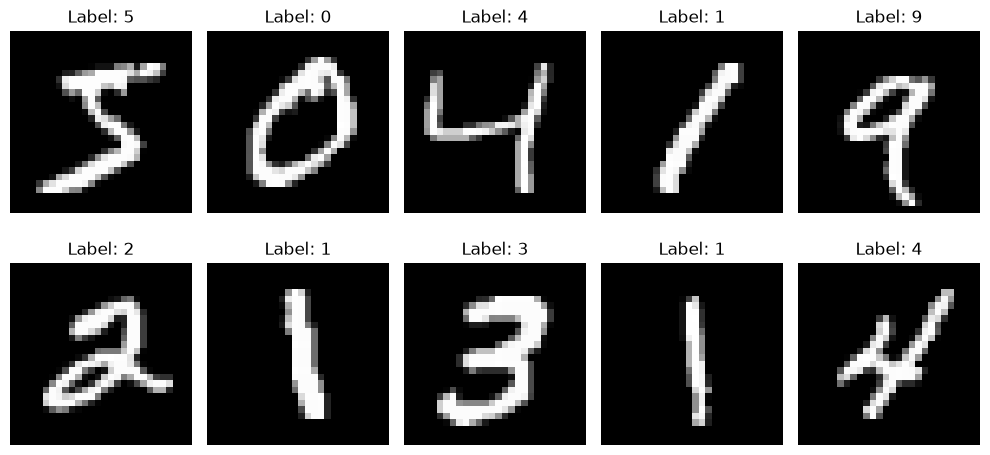

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Preprocess the Images

MNIST pixels are stored from 0 to 255. We normalize them to 0–1 and add a channel dimension because CNN input has the form `(height, width, channels)`.

In [5]:
# Convert pixels from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (60000, 28, 28) -> (60000, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape after preprocessing:", x_train.shape)
print("Testing shape after preprocessing :", x_test.shape)
print("New pixel range:", x_train.min(), "to", x_train.max())

Training shape after preprocessing: (60000, 28, 28, 1)
Testing shape after preprocessing : (10000, 28, 28, 1)
New pixel range: 0.0 to 1.0


## 6. Build the CNN Model

Architecture:

`Input → Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Dropout → Output`

In [6]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
], name="MNIST_CNN")

model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile the CNN

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 8. Train the CNN

The model learns from the 60,000 training images. A 10% validation split is used to monitor performance during training.

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9168 - loss: 0.2730 - val_accuracy: 0.9820 - val_loss: 0.0615
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9767 - loss: 0.0804 - val_accuracy: 0.9862 - val_loss: 0.0425
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9830 - loss: 0.0563 - val_accuracy: 0.9897 - val_loss: 0.0375
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9859 - loss: 0.0451 - val_accuracy: 0.9903 - val_loss: 0.0356
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9888 - loss: 0.0366 - val_accuracy: 0.9897 - val_loss: 0.0341


## 9. Evaluate the Model on 10,000 Test Images

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

Test Loss     : 0.0285
Test Accuracy : 99.04%


## 10. Plot Training and Validation Accuracy

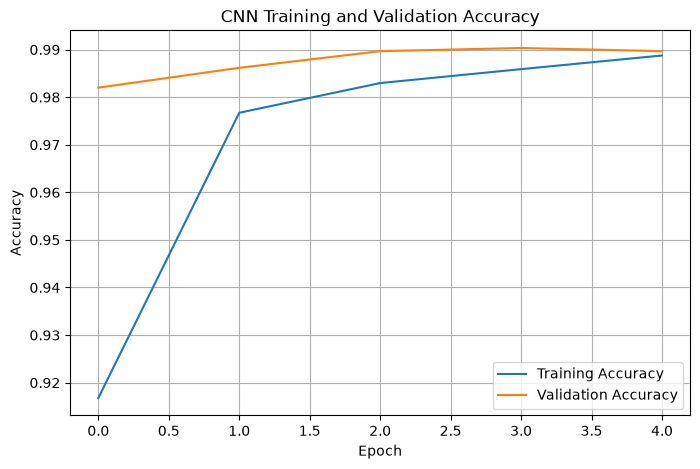

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 11. Plot Training and Validation Loss

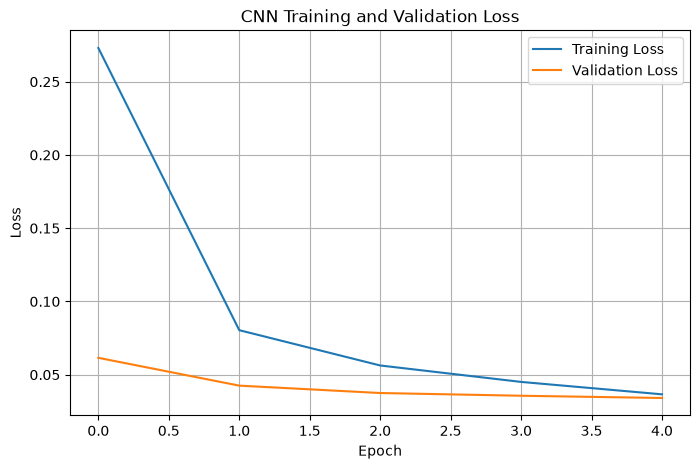

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 12. Predict Test Images

In [12]:
probabilities = model.predict(x_test, batch_size=256, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

print("First 20 actual labels   :", y_test[:20])
print("First 20 predicted labels:", y_pred[:20])

First 20 actual labels   : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
First 20 predicted labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 5 4]


## 13. Display Predictions

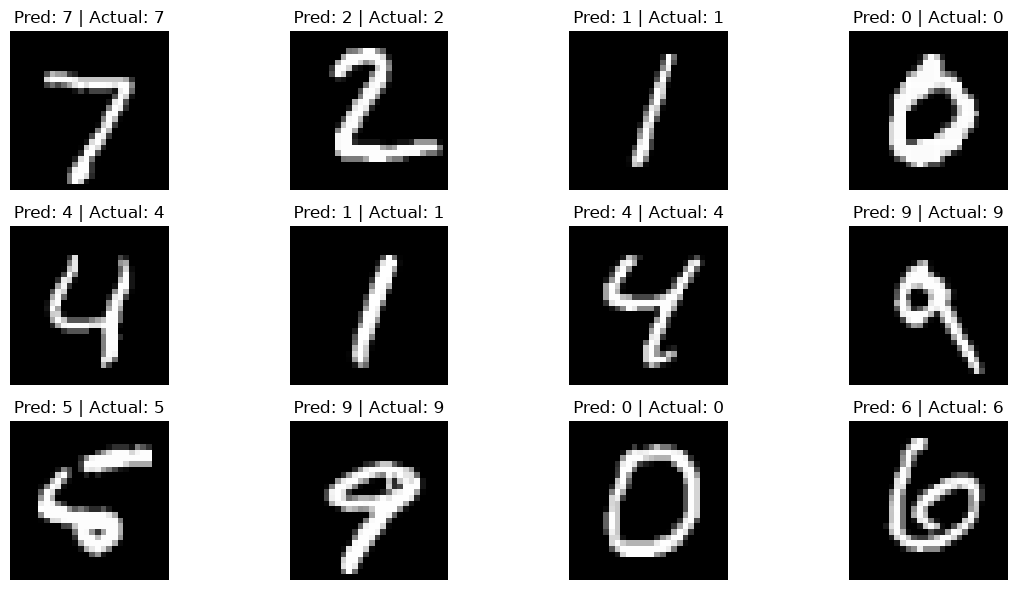

In [13]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    predicted = y_pred[i]
    actual = y_test[i]
    title = f"Pred: {predicted} | Actual: {actual}"
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Confusion Matrix

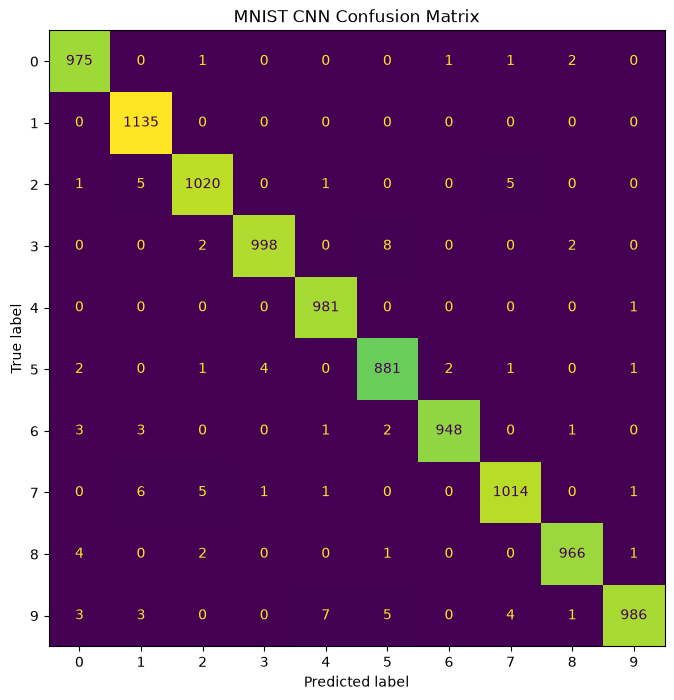

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("MNIST CNN Confusion Matrix")
plt.show()

## 15. Classification Report

In [15]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9868    0.9949    0.9909       980
           1     0.9852    1.0000    0.9926      1135
           2     0.9893    0.9884    0.9889      1032
           3     0.9950    0.9881    0.9916      1010
           4     0.9899    0.9990    0.9944       982
           5     0.9822    0.9877    0.9849       892
           6     0.9968    0.9896    0.9932       958
           7     0.9893    0.9864    0.9878      1028
           8     0.9938    0.9918    0.9928       974
           9     0.9960    0.9772    0.9865      1009

    accuracy                         0.9904     10000
   macro avg     0.9904    0.9903    0.9903     10000
weighted avg     0.9904    0.9904    0.9904     10000



## 16. Test One Image Manually

Change `image_index` to test different MNIST images.

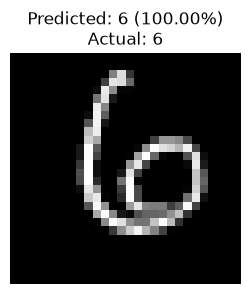

Predicted digit: 6
Confidence: 100.00%
Actual digit: 6


In [16]:
image_index = 100

image = x_test[image_index]
prediction = model.predict(image.reshape(1, 28, 28, 1), verbose=0)[0]
predicted_digit = np.argmax(prediction)
confidence = prediction[predicted_digit] * 100

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Predicted: {predicted_digit} ({confidence:.2f}%)\nActual: {y_test[image_index]}")
plt.axis("off")
plt.show()

print("Predicted digit:", predicted_digit)
print(f"Confidence: {confidence:.2f}%")
print("Actual digit:", y_test[image_index])

## 17. Save the Trained CNN Model

The saved model will later be loaded by the Flask web application.

In [17]:
os.makedirs("models", exist_ok=True)

model_path = "models/mnist_cnn.keras"
model.save(model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
models/mnist_cnn.keras


## 18. Project Result

The trained CNN can classify handwritten digits into ten classes: **0, 1, 2, 3, 4, 5, 6, 7, 8, and 9**.

The saved `.keras` model can be connected to the Flask application for real-time handwritten digit prediction.